In [30]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
 
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import class_weight
 
from imblearn.over_sampling import SMOTE   # pip install imbalanced-learn
 
# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping
 
print("All libraries imported successfully!")

All libraries imported successfully!


In [31]:
# 2. LOAD DATA
data = pd.read_csv("Bank_Transaction_Fraud_Detection.csv")

In [32]:
# 2a. Basic shape and preview
print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"\n📐 Shape         : {data.shape[0]} rows × {data.shape[1]} columns")
print(f"📋 Total Features: {data.shape[1] - 1}  |  Target: 'Is_Fraud'")
 
print("\n── First 5 Rows ──")
print(data.head())
 
print("\n── Last 5 Rows ──")
print(data.tail())
 
print("\n── Random Sample (5 rows) ──")
print(data.sample(5, random_state=42))

  DATASET OVERVIEW

📐 Shape         : 200000 rows × 24 columns
📋 Total Features: 23  |  Target: 'Is_Fraud'

── First 5 Rows ──
                            Customer_ID        Customer_Name  Gender  Age  \
0  d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e           Osha Tella    Male   60   
1  7c14ad51-781a-4db9-b7bd-67439c175262      Hredhaan Khosla  Female   51   
2  3a73a0e5-d4da-45aa-85f3-528413900a35       Ekani Nazareth    Male   20   
3  7902f4ef-9050-4a79-857d-9c2ea3181940  Yamini Ramachandran  Female   57   
4  3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9         Kritika Rege  Female   43   

         State                City                Bank_Branch Account_Type  \
0       Kerala  Thiruvananthapuram  Thiruvananthapuram Branch      Savings   
1  Maharashtra              Nashik              Nashik Branch     Business   
2        Bihar           Bhagalpur           Bhagalpur Branch      Savings   
3   Tamil Nadu             Chennai             Chennai Branch     Business   
4       Punjab      

In [33]:
# 2b. Column data types and non-null counts
print("\n── Column Info ──")
print(data.info())
 
print("\n── Data Types Summary ──")
print(data.dtypes.value_counts())
print("\nColumn-wise dtypes:")
print(data.dtypes)


── Column Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Type         200000 non-null

In [34]:
# 2c. Statistical summary
print("\n── Statistical Summary (Numeric Columns) ──")
print(data.describe().T.to_string())
 
print("\n── Statistical Summary (Categorical Columns) ──")
cat_cols_raw = data.select_dtypes(include=['object']).columns
if len(cat_cols_raw) > 0:
    print(data[cat_cols_raw].describe())
else:
    print("No categorical columns found.")


── Statistical Summary (Numeric Columns) ──
                       count          mean           std      min        25%        50%        75%       max
Age                 200000.0     44.015110     15.288774    18.00     31.000     44.000     57.000     70.00
Transaction_Amount  200000.0  49538.015554  28551.874004    10.29  24851.345  49502.440  74314.625  98999.98
Account_Balance     200000.0  52437.988784  27399.507128  5000.82  28742.395  52372.555  76147.670  99999.95
Is_Fraud            200000.0      0.050440      0.218852     0.00      0.000      0.000      0.000      1.00

── Statistical Summary (Categorical Columns) ──
                                 Customer_ID Customer_Name  Gender     State  \
count                                 200000        200000  200000    200000   
unique                                200000        142699       2        34   
top     d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e   Aahana Kala    Male  Nagaland   
freq                                     

In [35]:
# 2d. Missing values analysis
print("\n── Missing Values ──")
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if missing_df.empty:
    print("✅ No missing values found in the dataset!")
else:
    print(missing_df)


── Missing Values ──
✅ No missing values found in the dataset!


In [36]:
# 2e. Duplicate rows check
dup_count = data.duplicated().sum()
print(f"\n── Duplicate Rows ──")
print(f"Total duplicates: {dup_count}")
if dup_count > 0:
    print("⚠️  Duplicates found! Consider removing them.")
    data = data.drop_duplicates()
    print(f"✅ Removed. New shape: {data.shape}")
else:
    print("✅ No duplicates found.")


── Duplicate Rows ──
Total duplicates: 0
✅ No duplicates found.


In [37]:
# 2f. Unique value counts per column
print("\n── Unique Values per Column ──")
unique_counts = data.nunique().sort_values()
print(unique_counts.to_string())


── Unique Values per Column ──
Transaction_Currency            1
Gender                          2
Is_Fraud                        2
Account_Type                    3
Device_Type                     4
Transaction_Type                5
Merchant_Category               6
Transaction_Device             20
Transaction_Date               31
State                          34
Age                            53
City                          145
Bank_Branch                   145
Transaction_Location          148
Transaction_Description       172
Customer_Email               4779
Customer_Contact             9000
Transaction_Time            77856
Customer_Name              142699
Account_Balance            197954
Transaction_Amount         197978
Merchant_ID                200000
Customer_ID                200000
Transaction_ID             200000


In [38]:
# 2g. Categorical column value distributions
print("\n── Categorical Column Value Counts ──")
for col in cat_cols_raw:
    print(f"\n▶ {col}  ({data[col].nunique()} unique values):")
    print(data[col].value_counts().head(10))


── Categorical Column Value Counts ──

▶ Customer_ID  (200000 unique values):
Customer_ID
d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e    1
7c14ad51-781a-4db9-b7bd-67439c175262    1
3a73a0e5-d4da-45aa-85f3-528413900a35    1
7902f4ef-9050-4a79-857d-9c2ea3181940    1
3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9    1
6c870d65-76b0-431d-bdf3-9292998e8211    1
5323737c-bbd2-423f-9c9b-e0433c8f75dc    1
c0c3d474-f6c2-4c66-9b0e-f9ba75c6f310    1
e9a82764-1253-4a46-ad34-80e3416fc801    1
708224d5-192a-4d86-b411-8ec6d1bb274b    1
Name: count, dtype: int64

▶ Customer_Name  (142699 unique values):
Customer_Name
Aahana Kala         8
Madhav Kala         7
Jonathan Dara       7
Mitali Lad          7
Krishna Nori        7
Lila Dutt           7
Krishna Sani        7
Harsh Dara          7
Yash Patla          6
Reyansh Deshmukh    6
Name: count, dtype: int64

▶ Gender  (2 unique values):
Gender
Male      100452
Female     99548
Name: count, dtype: int64

▶ State  (34 unique values):
State
Nagaland          6031
Megha

In [39]:
# 2h. Target variable check
print("\n── Target Variable: Is_Fraud ──")
fraud_counts = data['Is_Fraud'].value_counts()
fraud_pct    = data['Is_Fraud'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': fraud_counts, 'Percentage': fraud_pct.round(2)}))
print(f"\n⚠️  Imbalance Ratio → {fraud_counts[0]}:{fraud_counts[1]}"
      f"  (Only {fraud_pct[1]:.2f}% are fraud)")
print("→ This confirms we NEED SMOTE / class weighting to handle imbalance.")


── Target Variable: Is_Fraud ──
           Count  Percentage
Is_Fraud                    
0         189912       94.96
1          10088        5.04

⚠️  Imbalance Ratio → 189912:10088  (Only 5.04% are fraud)
→ This confirms we NEED SMOTE / class weighting to handle imbalance.


# 3. EDA - EXPLORATORY DATA ANALYSIS

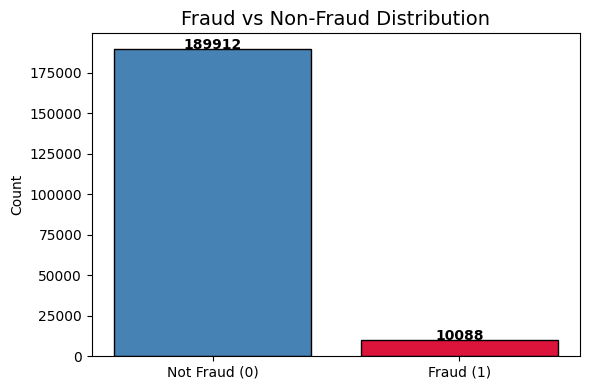


Class Imbalance Ratio  →  189912:10088  (5.04% fraud)


In [40]:

# 3a. Fraud distribution
plt.figure(figsize=(6, 4))
counts = data['Is_Fraud'].value_counts()
plt.bar(['Not Fraud (0)', 'Fraud (1)'], counts.values,
        color=['steelblue', 'crimson'], edgecolor='black')
plt.title("Fraud vs Non-Fraud Distribution", fontsize=14)
plt.ylabel("Count")
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("eda_fraud_distribution.png", dpi=150)
plt.show()
print(f"\nClass Imbalance Ratio  →  {counts[0]}:{counts[1]}"
      f"  ({counts[1]/len(data)*100:.2f}% fraud)")
 

In [41]:
# 3b. Drop irrelevant columns (with reasoning)
print("\n── Dropping Irrelevant Columns ──")
drop_cols = [
    "Customer_ID", "Customer_Name", "Transaction_ID",
    "Customer_Contact", "Customer_Email",
    "Merchant_ID", "Transaction_Currency"
]
print(f"Columns to drop: {drop_cols}")
print("Reason: These are identifier/PII columns with no predictive signal.")
 
data = data.drop(drop_cols, axis=1)
print(f"Shape after dropping: {data.shape}")
print(f"Remaining columns: {list(data.columns)}")


── Dropping Irrelevant Columns ──
Columns to drop: ['Customer_ID', 'Customer_Name', 'Transaction_ID', 'Customer_Contact', 'Customer_Email', 'Merchant_ID', 'Transaction_Currency']
Reason: These are identifier/PII columns with no predictive signal.
Shape after dropping: (200000, 17)
Remaining columns: ['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Date', 'Transaction_Time', 'Transaction_Amount', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud', 'Transaction_Description']


In [42]:
# 3c. Numeric column statistics split by fraud label
print("\n── Mean of Numeric Features by Fraud Label ──")
num_cols = data.select_dtypes(include=['number']).columns.tolist()
num_cols_feat = [c for c in num_cols if c != 'Is_Fraud']
print(data.groupby('Is_Fraud')[num_cols_feat].mean().T.rename(
    columns={0: 'Not Fraud (mean)', 1: 'Fraud (mean)'}
))

# Std deviation
print("\n── Std Dev of Numeric Features by Fraud Label ──")
print(data.groupby('Is_Fraud')[num_cols_feat].std().T.rename(
    columns={0: 'Not Fraud (std)', 1: 'Fraud (std)'}
))
 
# Min / Max
print("\n── Min & Max of Numeric Features ──")
print(data[num_cols_feat].agg(['min', 'max']))


── Mean of Numeric Features by Fraud Label ──
Is_Fraud            Not Fraud (mean)  Fraud (mean)
Age                        44.020457     43.914453
Transaction_Amount      49551.831380  49277.925242
Account_Balance         52437.197166  52452.891412

── Std Dev of Numeric Features by Fraud Label ──
Is_Fraud            Not Fraud (std)   Fraud (std)
Age                       15.290050     15.265150
Transaction_Amount     28541.881772  28739.518843
Account_Balance        27404.829445  27300.467424

── Min & Max of Numeric Features ──
     Age  Transaction_Amount  Account_Balance
min   18               10.29          5000.82
max   70            98999.98         99999.95


In [43]:
# 3d. Outlier detection using IQR — BEFORE removal
print("\n── Outlier Detection (IQR Method) ──")
outlier_summary = {}
for col in num_cols_feat:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((data[col] < lower) | (data[col] > upper)).sum()
    outlier_summary[col] = {'Q1': round(Q1,2), 'Q3': round(Q3,2),
                             'IQR': round(IQR,2), 'Lower': round(lower,2),
                             'Upper': round(upper,2), 'Outliers': n_out}
 
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)
print(f"\nTotal outlier entries (non-fraud only will be removed later): {outlier_df['Outliers'].sum()}")


── Outlier Detection (IQR Method) ──
                          Q1        Q3       IQR     Lower      Upper  \
Age                    31.00     57.00     26.00     -8.00      96.00   
Transaction_Amount  24851.34  74314.62  49463.28 -49343.58  148509.54   
Account_Balance     28742.40  76147.67  47405.27 -42365.52  147255.58   

                    Outliers  
Age                      0.0  
Transaction_Amount       0.0  
Account_Balance          0.0  

Total outlier entries (non-fraud only will be removed later): 0.0


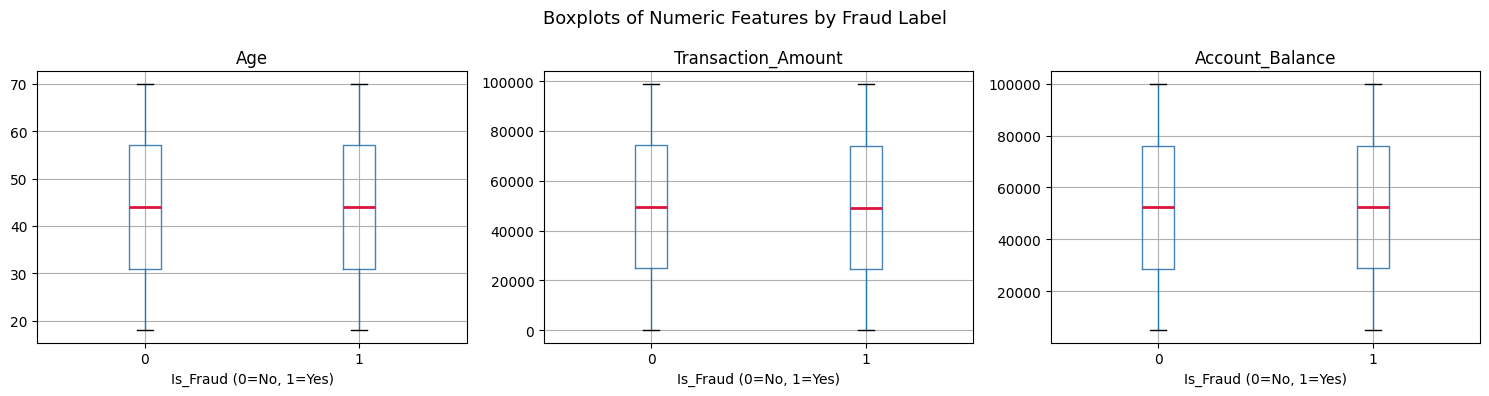

✅ Plotted 3 numeric feature(s): ['Age', 'Transaction_Amount', 'Account_Balance']


In [44]:
# 3e. Boxplots for numeric features — dynamic grid
n_cols_plot = len(num_cols_feat)
ncols = min(3, n_cols_plot)
nrows = (n_cols_plot + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)  # ← works for (1,3), (2,3), or (1,) shapes

for i, col in enumerate(num_cols_feat):
    data.boxplot(column=col, by='Is_Fraud', ax=axes[i],
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='crimson', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xlabel("Is_Fraud (0=No, 1=Yes)")

# Hide unused subplots
for j in range(len(num_cols_feat), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots of Numeric Features by Fraud Label", fontsize=13)
plt.tight_layout()
plt.savefig("eda_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plotted {n_cols_plot} numeric feature(s): {num_cols_feat}")

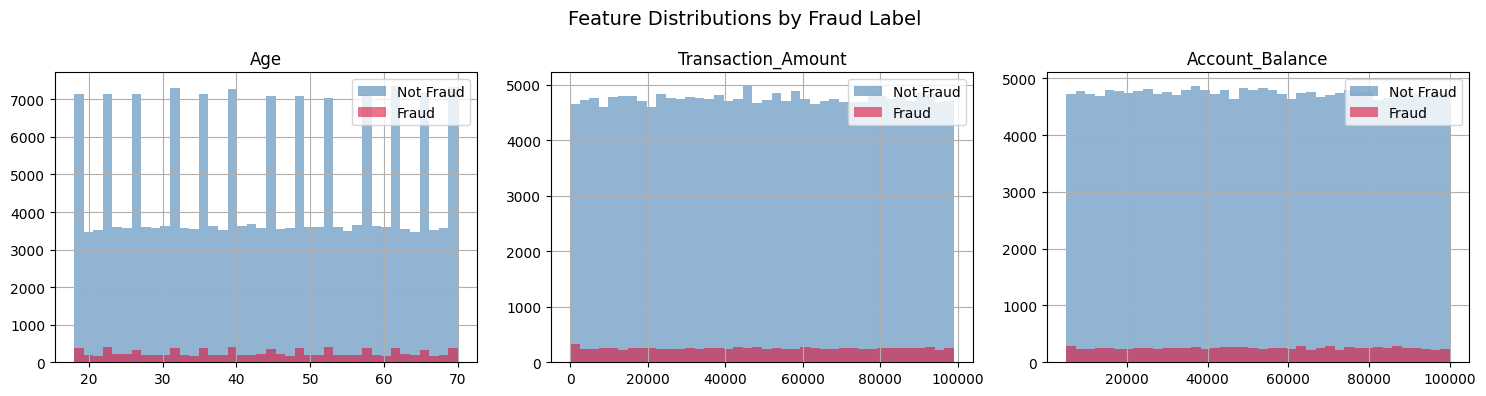

In [45]:
# 3f. Histograms — feature distributions by fraud label
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for i, col in enumerate(num_cols_feat):
    data[data['Is_Fraud'] == 0][col].hist(
        bins=40, alpha=0.6, color='steelblue', label='Not Fraud', ax=axes[i])
    data[data['Is_Fraud'] == 1][col].hist(
        bins=40, alpha=0.6, color='crimson', label='Fraud', ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)  # ← hides empty subplots

plt.suptitle("Feature Distributions by Fraud Label", fontsize=14)
plt.tight_layout()
plt.savefig("eda_feature_distributions.png", dpi=150)
plt.show()

In [46]:
# 3g. Categorical feature analysis (before encoding)
cat_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f"\n── Categorical Columns ({len(cat_cols)}): {cat_cols} ──")
for col in cat_cols:
    print(f"\n▶ {col}")
    freq = data.groupby(col)['Is_Fraud'].agg(['count','sum'])
    freq.columns = ['Total', 'Fraud_Count']
    freq['Fraud_Rate%'] = (freq['Fraud_Count'] / freq['Total'] * 100).round(2)
    freq = freq.sort_values('Fraud_Rate%', ascending=False)
    print(freq.head(10))
    print(f"  → Insight: Highest fraud rate in '{freq.index[0]}' at {freq['Fraud_Rate%'].iloc[0]}%")


── Categorical Columns (13): ['Gender', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Date', 'Transaction_Time', 'Transaction_Type', 'Merchant_Category', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Description'] ──

▶ Gender
         Total  Fraud_Count  Fraud_Rate%
Gender                                  
Male    100452         5081         5.06
Female   99548         5007         5.03
  → Insight: Highest fraud rate in 'Male' at 5.06%

▶ State
                Total  Fraud_Count  Fraud_Rate%
State                                          
Tamil Nadu       5841          328         5.62
Lakshadweep      5954          332         5.58
Sikkim           5793          312         5.39
Uttarakhand      5985          319         5.33
West Bengal      5851          311         5.32
Madhya Pradesh   5928          315         5.31
Mizoram          5892          312         5.30
Telangana        5952          315         5.29
Karnataka        5775    

In [48]:
# 4. ENCODING
 
print("\n── Before Encoding — Categorical Column Samples ──")
cat_cols_enc = data.select_dtypes(include=['object']).columns
for col in cat_cols_enc:
    print(f"  {col}: {data[col].unique()[:8]}")
 
for col in cat_cols_enc:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    print(f"  ✔ Encoded '{col}'  →  {sorted(data[col].unique())[:8]}")
 
print("\n── After Encoding — Data Types ──")
print(data.dtypes)
print("\n── After Encoding — First 3 Rows ──")
print(data.head(3))
 



── Before Encoding — Categorical Column Samples ──

── After Encoding — Data Types ──
Gender                       int64
Age                          int64
State                        int64
City                         int64
Bank_Branch                  int64
Account_Type                 int64
Transaction_Date             int64
Transaction_Time             int64
Transaction_Amount         float64
Transaction_Type             int64
Merchant_Category            int64
Account_Balance            float64
Transaction_Device           int64
Transaction_Location         int64
Device_Type                  int64
Is_Fraud                     int64
Transaction_Description      int64
dtype: object

── After Encoding — First 3 Rows ──
   Gender  Age  State  City  Bank_Branch  Account_Type  Transaction_Date  \
0       1   60     15   127          127             2                15   
1       0   51     18   100          100             0                 2   
2       1   20      4    13           1

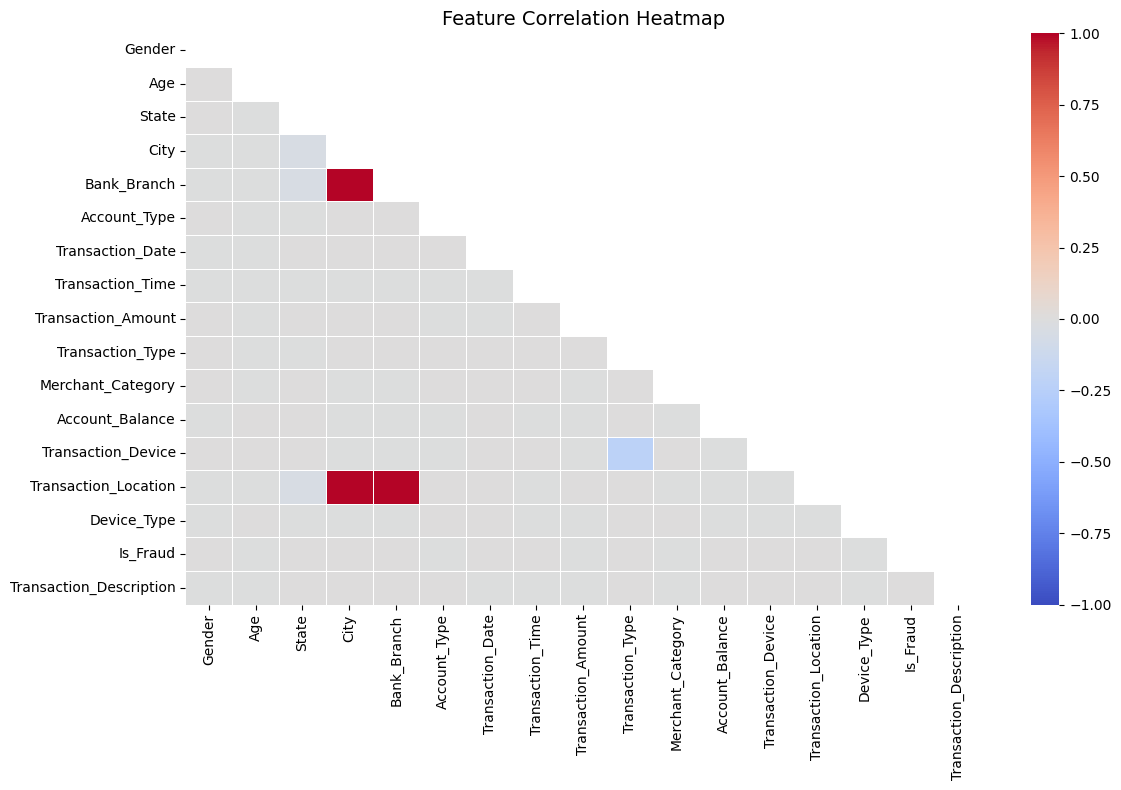


Top 10 Features Correlated with Fraud:
State                   0.005716
City                    0.002800
Bank_Branch             0.002800
Transaction_Location    0.002796
Account_Type            0.002592
Transaction_Amount      0.002100
Age                     0.001517
Merchant_Category       0.001342
Transaction_Device      0.001304
Transaction_Date        0.001150
Name: Is_Fraud, dtype: float64


In [49]:
# 4b. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150)
plt.show()
 
# Top correlations with Is_Fraud
fraud_corr = corr['Is_Fraud'].drop('Is_Fraud').abs().sort_values(ascending=False)
print("\nTop 10 Features Correlated with Fraud:")
print(fraud_corr.head(10))

In [50]:
# 5. SPLIT DATA
X = data.drop("Is_Fraud", axis=1)
y = data["Is_Fraud"]
 
print(f"\n── Feature Matrix (X) shape: {X.shape} ──")
print(f"── Target Vector (y) shape: {y.shape} ──")
print(f"\nFeature columns ({len(X.columns)}):")
print(list(X.columns))
 
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
 
print(f"\n── Train/Test Split (75/25 with stratify) ──")
print(f"  Train size : {x_train.shape[0]}  "
      f"(Fraud: {y_train.sum()}, Not Fraud: {(y_train==0).sum()})")
print(f"  Test  size : {x_test.shape[0]}  "
      f"(Fraud: {y_test.sum()}, Not Fraud: {(y_test==0).sum()})")
print(f"  Train fraud %: {y_train.mean()*100:.2f}%  "
      f"| Test fraud %: {y_test.mean()*100:.2f}%")
print("  ✅ Stratify ensures same fraud ratio in both splits.")
 


── Feature Matrix (X) shape: (200000, 16) ──
── Target Vector (y) shape: (200000,) ──

Feature columns (16):
['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Date', 'Transaction_Time', 'Transaction_Amount', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Description']

── Train/Test Split (75/25 with stratify) ──
  Train size : 150000  (Fraud: 7566, Not Fraud: 142434)
  Test  size : 50000  (Fraud: 2522, Not Fraud: 47478)
  Train fraud %: 5.04%  | Test fraud %: 5.04%
  ✅ Stratify ensures same fraud ratio in both splits.


In [51]:
# 6. OUTLIER REMOVAL (only on non-fraud train rows)
numerical_cols = x_train.select_dtypes(include=['number']).columns
mask = (y_train == 0)
 
for col in numerical_cols:
    Q1 = x_train.loc[mask, col].quantile(0.25)
    Q3 = x_train.loc[mask, col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask &= (x_train[col] >= lower) & (x_train[col] <= upper)
 
final_mask = mask | (y_train == 1)
x_train = x_train[final_mask]
y_train = y_train[final_mask]
print(f"\nAfter outlier removal → Train size: {x_train.shape[0]}")


After outlier removal → Train size: 150000


In [52]:
# 7. SCALING
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)
 
print("\n── After StandardScaler ──")
print(f"  Train mean (first 5 cols): {x_train_scaled[:, :5].mean(axis=0).round(4)}")
print(f"  Train std  (first 5 cols): {x_train_scaled[:, :5].std(axis=0).round(4)}")
print("  ✅ Fit on train only → applied to test (no data leakage).")


── After StandardScaler ──
  Train mean (first 5 cols): [ 0. -0. -0.  0.  0.]
  Train std  (first 5 cols): [1. 1. 1. 1. 1.]
  ✅ Fit on train only → applied to test (no data leakage).


In [53]:
# 8. SMOTE — FIX CLASS IMBALANCE
print(f"\n── Before SMOTE ──")
print(f"  Fraud: {y_train.sum()}  |  Not Fraud: {(y_train==0).sum()}")
print(f"  Fraud %: {y_train.mean()*100:.2f}%")
print("  ⚠️  Severe imbalance → models will predict majority class only.")
 
sm = SMOTE(random_state=42)
x_train_sm, y_train_sm = sm.fit_resample(x_train_scaled, y_train)
 
print(f"\n── After SMOTE ──")
print(f"  Fraud: {y_train_sm.sum()}  |  Not Fraud: {(y_train_sm==0).sum()}")
print(f"  Fraud %: {y_train_sm.mean()*100:.2f}%")
print("  ✅ Balanced! SMOTE generates synthetic minority samples.")


── Before SMOTE ──
  Fraud: 7566  |  Not Fraud: 142434
  Fraud %: 5.04%
  ⚠️  Severe imbalance → models will predict majority class only.

── After SMOTE ──
  Fraud: 142434  |  Not Fraud: 142434
  Fraud %: 50.00%
  ✅ Balanced! SMOTE generates synthetic minority samples.


In [54]:
# 9. MACHINE LEARNING MODELS
 
models = {
    "Random Forest":      RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Decision Tree":      DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "AdaBoost":           AdaBoostClassifier(n_estimators=100, random_state=42),
    "Logistic Regression":LogisticRegression(class_weight='balanced', max_iter=500, random_state=42),
    "Gradient Boosting":  GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes":        GaussianNB()
}
 
metrics = {
    'Model': [], 'Accuracy': [], 'Precision': [],
    'Recall': [], 'F1 Score': [], 'ROC-AUC': []
}
 
trained_models = {}
 
for name, model in models.items():
    model.fit(x_train_sm, y_train_sm)
    y_pred  = model.predict(x_test_scaled)
    y_proba = model.predict_proba(x_test_scaled)[:, 1]
 
    metrics['Model'].append(name)
    metrics['Accuracy'].append(round(accuracy_score(y_test, y_pred) * 100, 3))
    metrics['Precision'].append(round(precision_score(y_test, y_pred) * 100, 3))
    metrics['Recall'].append(round(recall_score(y_test, y_pred) * 100, 3))
    metrics['F1 Score'].append(round(f1_score(y_test, y_pred) * 100, 3))
    metrics['ROC-AUC'].append(round(roc_auc_score(y_test, y_proba) * 100, 3))
 
    trained_models[name] = (model, y_pred, y_proba)
    print(f"✔ {name} done")

✔ Random Forest done
✔ Decision Tree done
✔ AdaBoost done
✔ Logistic Regression done
✔ Gradient Boosting done
✔ Naive Bayes done


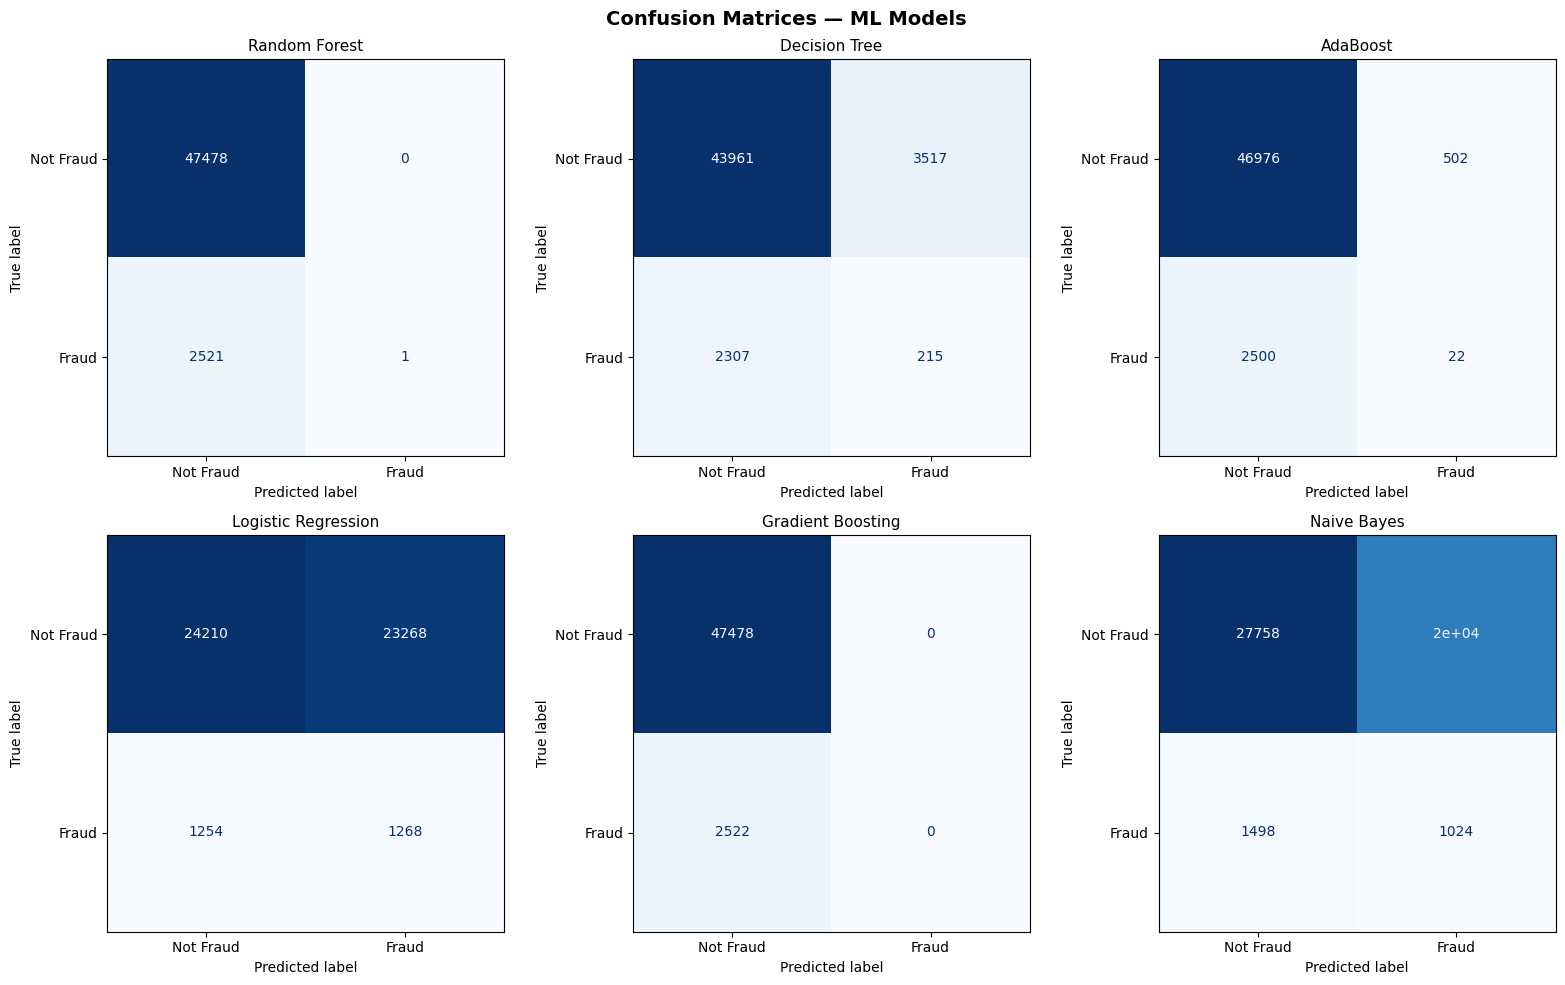

In [55]:
# 10. CONFUSION MATRICES FOR ML MODELS
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
 
for i, (name, (model, y_pred, _)) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=11)
 
plt.suptitle("Confusion Matrices — ML Models", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("cm_ml_models.png", dpi=150)
plt.show()

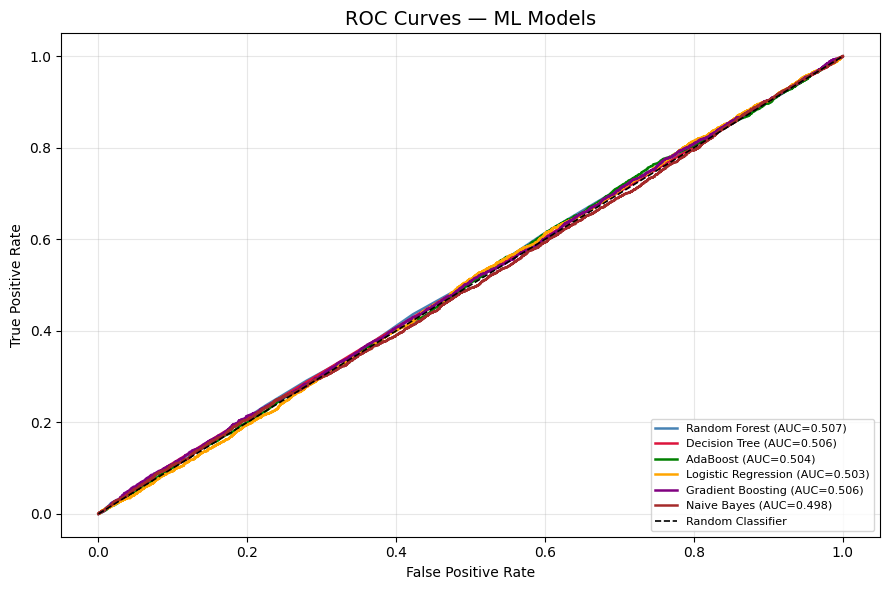

In [56]:
# 11. ROC CURVES FOR ML MODELS
plt.figure(figsize=(9, 6))
colors = ['steelblue','crimson','green','orange','purple','brown']
 
for (name, (_, __, y_proba)), color in zip(trained_models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=1.8)
 
plt.plot([0,1],[0,1],'k--', lw=1.2, label='Random Classifier')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — ML Models", fontsize=14)
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_ml_models.png", dpi=150)
plt.show()

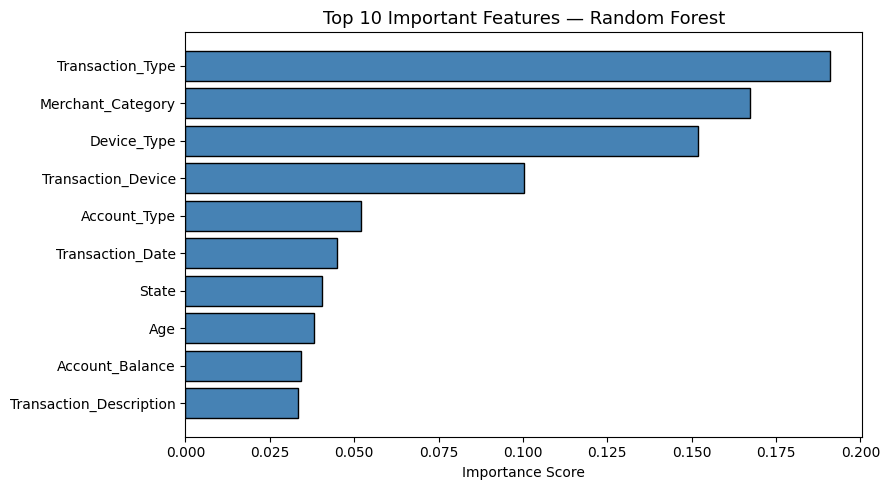


Top 10 Features:
                    Feature  Importance
9          Transaction_Type    0.190934
10        Merchant_Category    0.167391
14              Device_Type    0.151976
12       Transaction_Device    0.100380
5              Account_Type    0.052110
6          Transaction_Date    0.044761
2                     State    0.040479
1                       Age    0.038202
11          Account_Balance    0.034130
15  Transaction_Description    0.033425


In [57]:
# 12. FEATURE IMPORTANCE (Random Forest)
rf_model = trained_models["Random Forest"][0]
importances = rf_model.feature_importances_
feature_names = x_train.columns
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(10)
 
plt.figure(figsize=(9, 5))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
         color='steelblue', edgecolor='black')
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features — Random Forest", fontsize=13)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("\nTop 10 Features:")
print(feat_df)

In [58]:
# 13. CLASS WEIGHTS FOR DEEP LEARNING
cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_sm),
    y=y_train_sm
)
class_weights_dl = dict(enumerate(cw))
print("Class weights for DL:", class_weights_dl)
 
# Reshape for DL
x_train_dl = x_train_sm.reshape((x_train_sm.shape[0], x_train_sm.shape[1], 1))
x_test_dl  = x_test_scaled.reshape((x_test_scaled.shape[0], x_test_scaled.shape[1], 1))
 
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

Class weights for DL: {0: np.float64(1.0), 1: np.float64(1.0)}


In [59]:
# 14. LSTM MODEL
lstm_model = Sequential([
    Input(shape=(x_train_dl.shape[1], 1)),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
 
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()
 
history_lstm = lstm_model.fit(
    x_train_dl, y_train_sm,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights_dl,
    callbacks=[early_stop],
    verbose=1
)
 
# Find optimal threshold using Precision-Recall curve
y_scores_lstm = lstm_model.predict(x_test_dl).flatten()
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores_lstm)
f1_scores_thresh = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_thresh_lstm = thresholds[np.argmax(f1_scores_thresh[:-1])]
print(f"\nLSTM Best Threshold: {best_thresh_lstm:.3f}")
 
y_pred_lstm = (y_scores_lstm > best_thresh_lstm).astype("int32")
 
metrics['Model'].append("LSTM")
metrics['Accuracy'].append(round(accuracy_score(y_test, y_pred_lstm) * 100, 3))
metrics['Precision'].append(round(precision_score(y_test, y_pred_lstm) * 100, 3))
metrics['Recall'].append(round(recall_score(y_test, y_pred_lstm) * 100, 3))
metrics['F1 Score'].append(round(f1_score(y_test, y_pred_lstm) * 100, 3))
metrics['ROC-AUC'].append(round(roc_auc_score(y_test, y_scores_lstm) * 100, 3))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,193 (469.50 KB)

 Trainable params: 120,193 (469.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 53s 14ms/step - accuracy: 0.6245 - loss: 0.6462 - val_accuracy: 0.1132 - val_loss: 0.8991
Epoch 2/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 191s 54ms/step - accuracy: 0.6309 - loss: 0.6353 - val_accuracy: 0.4660 - val_loss: 0.8177
Epoch 3/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - accuracy: 0.6579 - loss: 0.6155 - val_accuracy: 0.4466 - val_loss: 0.7892
Epoch 4/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 70s 20ms/step - accuracy: 0.6892 - loss: 0.5848 - val_accuracy: 0.4221 - val_loss: 0.7496
Epoch 5/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - accuracy: 0.7384 - loss: 0.5246 - val_accuracy: 0.5613 - val_loss: 0.6176
Epoch 6/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - accuracy: 0.8108 - loss: 0.4286 - val_accuracy: 0.6048 - val_loss: 0.6490
Epoch 7/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - accuracy: 0.8453 - loss: 0.3785 - val_accuracy: 0.7192 - val_loss: 0.4542
Epoch 8/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - accuracy: 0.8586 

In [60]:
# 15. TRANSFORMER MODEL
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x + inputs)
    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dropout(dropout)(ffn)
    ffn = Dense(inputs.shape[-1])(ffn)
    return LayerNormalization(epsilon=1e-6)(x + ffn)
 
inputs = Input(shape=(x_train_dl.shape[1], 1))
x = transformer_encoder(inputs, 64, 4, 128)
x = transformer_encoder(x, 64, 4, 128)
x = transformer_encoder(x, 64, 4, 128)
x = GlobalAveragePooling1D()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid")(x)
 
transformer_model = Model(inputs, outputs)
transformer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
transformer_model.summary()
 
history_trans = transformer_model.fit(
    x_train_dl, y_train_sm,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights_dl,
    callbacks=[early_stop],
    verbose=1
)
 
# Optimal threshold
y_scores_trans = transformer_model.predict(x_test_dl).flatten()
precisions_t, recalls_t, thresholds_t = precision_recall_curve(y_test, y_scores_trans)
f1_scores_t = 2 * precisions_t * recalls_t / (precisions_t + recalls_t + 1e-8)
best_thresh_trans = thresholds_t[np.argmax(f1_scores_t[:-1])]
print(f"\nTransformer Best Threshold: {best_thresh_trans:.3f}")
 
y_pred_trans = (y_scores_trans > best_thresh_trans).astype("int32")
 
metrics['Model'].append("Transformer")
metrics['Accuracy'].append(round(accuracy_score(y_test, y_pred_trans) * 100, 3))
metrics['Precision'].append(round(precision_score(y_test, y_pred_trans) * 100, 3))
metrics['Recall'].append(round(recall_score(y_test, y_pred_trans) * 100, 3))
metrics['F1 Score'].append(round(f1_score(y_test, y_pred_trans) * 100, 3))
metrics['ROC-AUC'].append(round(roc_auc_score(y_test, y_scores_trans) * 100, 3))

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 16, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 1)     │      1,793 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 1)     │          0 │ dropout_3[0][0],  │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 16, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 16, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16, 1)     │        129 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 1)     │          2 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 1)     │      1,793 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 16, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 16, 1)     │          0 │ dropout_6[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 1)     │          2 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 16, 128)   │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16, 1)     │        129 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 16, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 1)     │          2 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,739 (26.32 KB)

 Trainable params: 6,739 (26.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 87s 23ms/step - accuracy: 0.6250 - loss: 0.6640 - val_accuracy: 0.0000e+00 - val_loss: 0.9647
Epoch 2/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 85s 24ms/step - accuracy: 0.6250 - loss: 0.6616 - val_accuracy: 0.0000e+00 - val_loss: 0.9794
Epoch 3/20
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 90s 25ms/step - accuracy: 0.6250 - loss: 0.6616 - val_accuracy: 0.0000e+00 - val_loss: 0.9795
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step

Transformer Best Threshold: 0.381


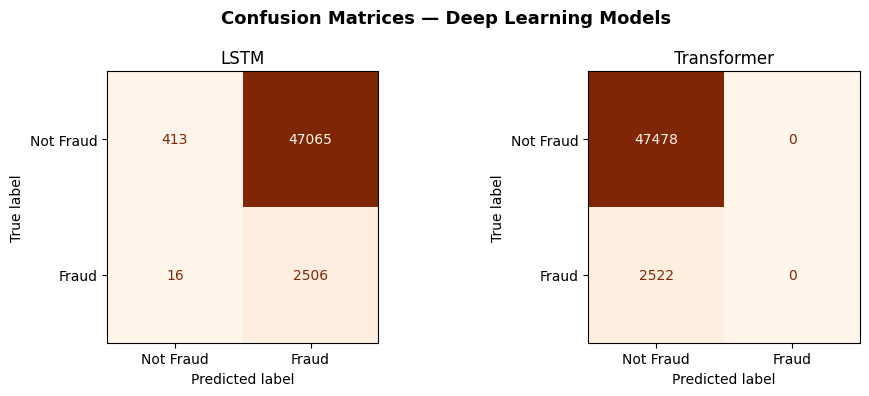

In [61]:
# 16. DL — CONFUSION MATRICES
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, y_pred in zip(axes,
                              ["LSTM", "Transformer"],
                              [y_pred_lstm, y_pred_trans]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not Fraud', 'Fraud']).plot(
        ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(name, fontsize=12)
plt.suptitle("Confusion Matrices — Deep Learning Models", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("cm_dl_models.png", dpi=150)
plt.show()

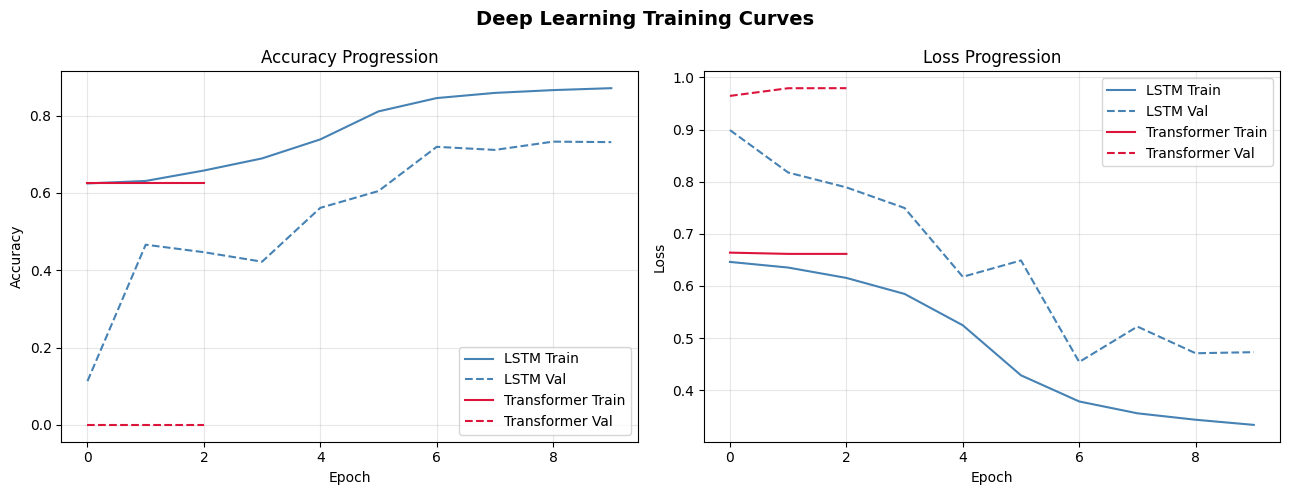

In [62]:
# 17. ACCURACY & LOSS CURVES (DL)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Accuracy
axes[0].plot(history_lstm.history['accuracy'],  label='LSTM Train',       color='steelblue')
axes[0].plot(history_lstm.history['val_accuracy'], label='LSTM Val',      color='steelblue', linestyle='--')
axes[0].plot(history_trans.history['accuracy'], label='Transformer Train', color='crimson')
axes[0].plot(history_trans.history['val_accuracy'], label='Transformer Val', color='crimson', linestyle='--')
axes[0].set_title("Accuracy Progression"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)
 
# Loss
axes[1].plot(history_lstm.history['loss'],       label='LSTM Train',       color='steelblue')
axes[1].plot(history_lstm.history['val_loss'],   label='LSTM Val',         color='steelblue', linestyle='--')
axes[1].plot(history_trans.history['loss'],      label='Transformer Train', color='crimson')
axes[1].plot(history_trans.history['val_loss'],  label='Transformer Val',   color='crimson', linestyle='--')
axes[1].set_title("Loss Progression"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
 
plt.suptitle("Deep Learning Training Curves", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("dl_training_curves.png", dpi=150)
plt.show()


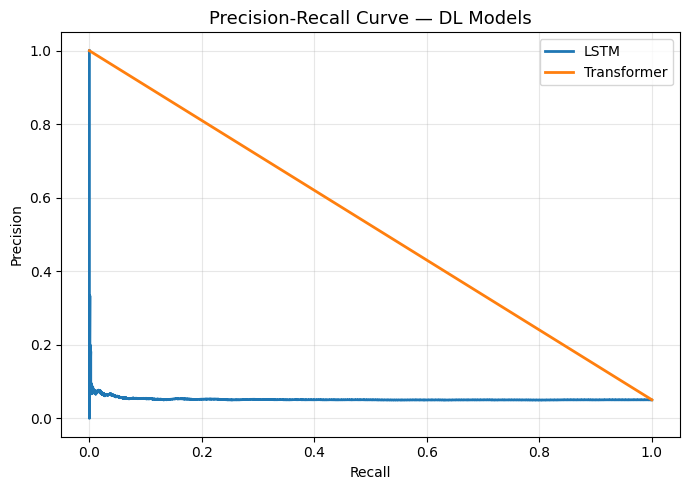

In [63]:
# 18. PRECISION-RECALL CURVES (DL)
plt.figure(figsize=(7, 5))
for name, scores in [("LSTM", y_scores_lstm), ("Transformer", y_scores_trans)]:
    p, r, _ = precision_recall_curve(y_test, scores)
    plt.plot(r, p, label=name, lw=2)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve — DL Models", fontsize=13)
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pr_curve_dl.png", dpi=150)
plt.show()

In [64]:
# 19. FINAL COMPARISON TABLE
metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
 
print("\n" + "="*75)
print("            FINAL MODEL COMPARISON (sorted by F1 Score)")
print("="*75)
print(metrics_df.to_string(index=False))
print("="*75)


            FINAL MODEL COMPARISON (sorted by F1 Score)
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
               LSTM     5.838      5.055  99.366     9.621   50.028
Logistic Regression    50.956      5.168  50.278     9.372   50.275
        Naive Bayes    57.564      4.936  40.603     8.803   49.818
      Decision Tree    88.352      5.761   8.525     6.876   50.559
           AdaBoost    93.996      4.198   0.872     1.445   50.374
      Random Forest    94.958    100.000   0.040     0.079   50.721
  Gradient Boosting    94.956      0.000   0.000     0.000   50.649
        Transformer    94.956      0.000   0.000     0.000   50.000


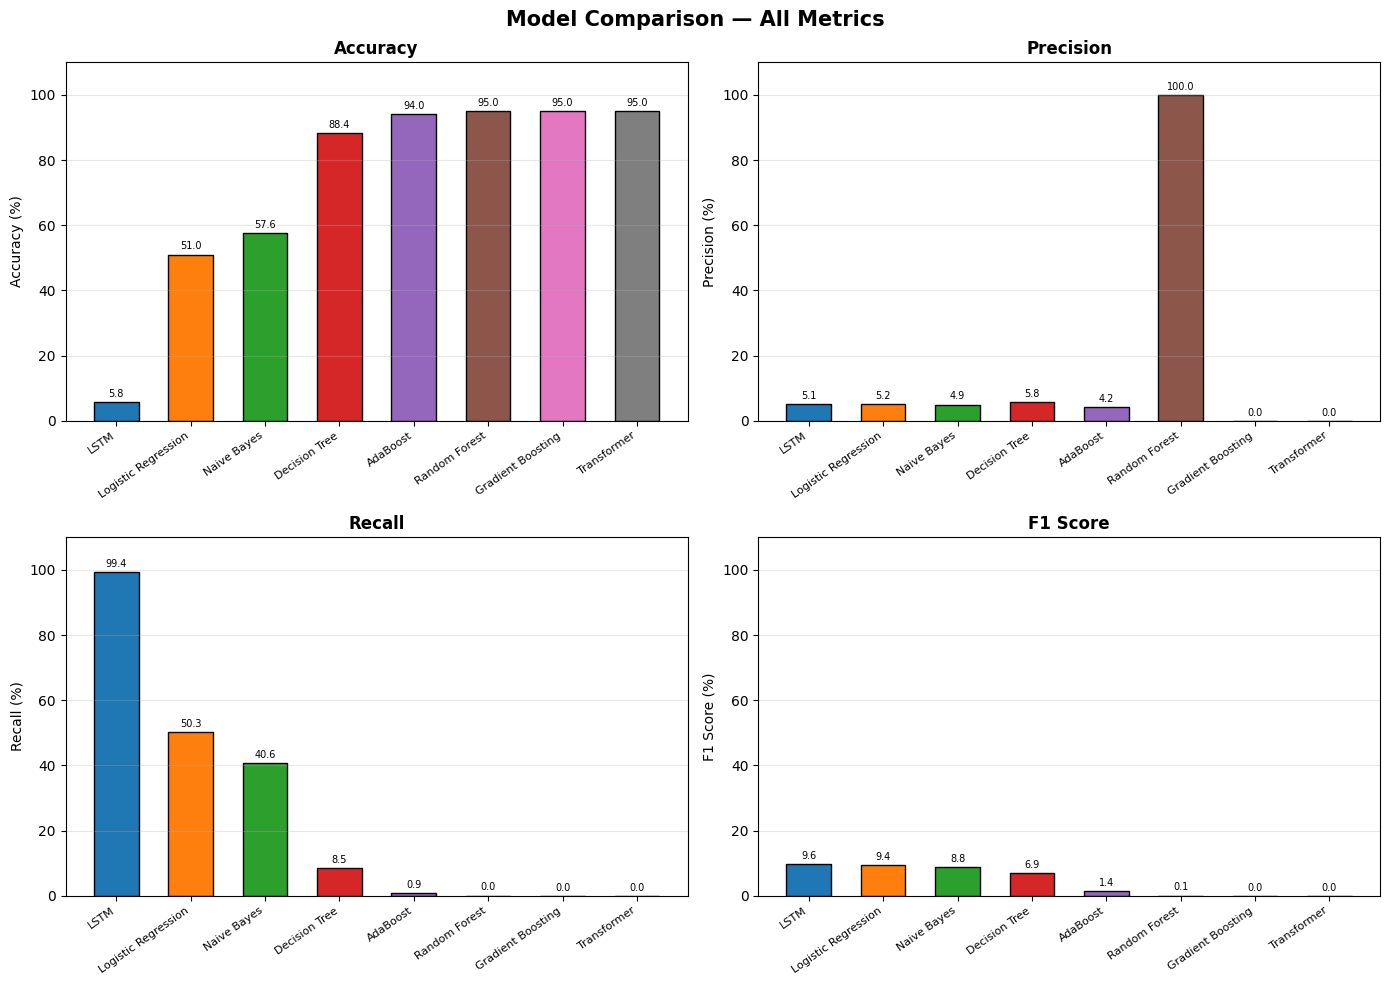


✅ Project Complete! All plots saved.


In [66]:
# 20. FINAL COMPARISON BAR CHART
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors_bar  = plt.cm.tab10.colors
 
for ax, col in zip(axes.flatten(), metric_cols):
    bars = ax.bar(metrics_df['Model'], metrics_df[col],
                  color=colors_bar[:len(metrics_df)], edgecolor='black', width=0.6)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel(f"{col} (%)")
    ax.set_xticklabels(metrics_df['Model'], rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, 110)
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f"{h:.1f}", ha='center', va='bottom', fontsize=7)
 
plt.suptitle("Model Comparison — All Metrics", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("final_comparison.png", dpi=150)
plt.show()
 
print("\n✅ Project Complete! All plots saved.")